# `mcsim` example use

A runnable walk-through of the Monte Carlo driver using only the currently-implemented pieces
(the univariate ARMA DGP, the AR(p) estimator, and the closed-form IRF). It shows the three contracts:

* **DGP** — a callable `(rng, T) -> data`.
* **Estimators** — callables `(data) -> irf_array`, built with `partial` so a whole *sweep* of lag orders shares one interface.
* **Scoring** — done *after* `run`, against the true IRF, so changing the DGP doesn't require re-running anything.

To build the real baseline, swap the ARMA DGP for the bivariate VAR(4) and the AR estimator for `estimate_var_irf` / `estimate_lp_irf` — the `run` call stays identical.

In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import ARMASpec, arma_irf, simulate_arma
from mcsim.estimators import estimate_ar_irf
from mcsim.simulation import MCConfig, run

## 1. Define the DGP

A stationary AR(2). Its IRF is rich enough that an *under*-specified AR(1) estimator is visibly biased while AR(2)/AR(3) recover it — a univariate echo of the lag-order theme in the baseline study.

The adapter `arma_dgp` matches the `(rng, T) -> data` contract. (In a notebook a closure would also work, but a named function pickles cleanly for `n_jobs != 1`.)

In [2]:
DGP_SPEC = ARMASpec(ar=(0.5, 0.3), sigma=1.0)

def arma_dgp(rng, T, spec):
    return simulate_arma(spec, T, rng)

dgp = partial(arma_dgp, spec=DGP_SPEC)

## 2. Configure the experiment

The estimator dict is a small *order sweep*: the same estimator at lag orders 1, 2, 3, each bound to the `(data) -> irf` contract via `partial`. This is exactly the pattern the baseline uses for the 24-estimator LP + VAR sweep.

In [3]:
horizon = 20

cfg = MCConfig(
    n_reps=2000,
    T=240,
    horizon=horizon,
    seed=20260527,
    n_jobs=-1,
    progress=True,
    estimators={
        f"AR({p})": partial(estimate_ar_irf, p=p, horizon=horizon)
        for p in (1, 2, 3)
    },
)
cfg

MCConfig(n_reps=2000, T=240, horizon=20, seed=20260527, n_jobs=-1, estimators={'AR(1)': functools.partial(<function estimate_ar_irf at 0x110f739d0>, p=1, horizon=20), 'AR(2)': functools.partial(<function estimate_ar_irf at 0x110f739d0>, p=2, horizon=20), 'AR(3)': functools.partial(<function estimate_ar_irf at 0x110f739d0>, p=3, horizon=20)}, progress=True)

## 3. Run the Monte Carlo

`run` returns the *raw* stacked IRF estimates, shape `(n_reps, horizon + 1)` per estimator, plus a per-estimator failure count.

In [4]:
results = run(dgp, cfg)

print({k: v.shape for k, v in results["irfs"].items()})
print("failures:", results["n_failures"])

MC reps: 100%|██████████| 2000/2000 [00:00<00:00, 7752.84it/s]

{'AR(1)': (2000, 21), 'AR(2)': (2000, 21), 'AR(3)': (2000, 21)}
failures: {'AR(1)': 0, 'AR(2)': 0, 'AR(3)': 0}


## 4. Score against the true IRF

Because the DGP is known, the estimand has a closed form (`arma_irf`). We compute bias and RMSE per horizon *after* the run, NaN-safe against any failed replications.

In [5]:
truth = arma_irf(DGP_SPEC, horizon)  # shape (horizon + 1,)

bias = {name: np.nanmean(stack - truth, axis=0) for name, stack in results["irfs"].items()}
rmse = {name: np.sqrt(np.nanmean((stack - truth) ** 2, axis=0)) for name, stack in results["irfs"].items()}

report = [0, 1, 2, 5, 10, 20]
print("RMSE by horizon")
print("estimator | " + " | ".join(f"h={h:<2d}" for h in report))
for name, r in rmse.items():
    print(f"{name:>9s} | " + " | ".join(f"{r[h]:.3f}" for h in report))

RMSE by horizon
estimator | h=0  | h=1  | h=2  | h=5  | h=10 | h=20
    AR(1) | 0.000 | 0.214 | 0.101 | 0.151 | 0.107 | 0.026
    AR(2) | 0.000 | 0.061 | 0.049 | 0.067 | 0.058 | 0.026
    AR(3) | 0.000 | 0.065 | 0.071 | 0.071 | 0.062 | 0.029


## 5. Plot RMSE across the horizon

The under-specified AR(1) sits above the correctly-specified AR(2); AR(3) pays a small variance cost for the extra lag.

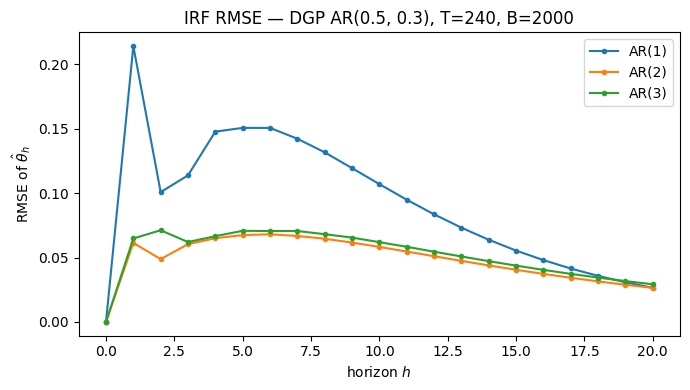

In [6]:
h = np.arange(horizon + 1)
fig, ax = plt.subplots(figsize=(7, 4))
for name, r in rmse.items():
    ax.plot(h, r, marker="o", ms=3, label=name)
ax.set_xlabel("horizon $h$")
ax.set_ylabel("RMSE of $\\hat{\\theta}_h$")
ax.set_title(f"IRF RMSE — DGP AR{tuple(DGP_SPEC.ar)}, T={cfg.T}, B={cfg.n_reps}")
ax.legend()
fig.tight_layout()
plt.show()